In [1]:
# Import initial libraries
import pandas as pd
import numpy as np
import boto3
from io import StringIO
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load your modeling dataset from S3
# Replace the path below with your actual S3 path from Day 26
s3 = boto3.client('s3')
bucket_name = 'cmse492-cranda98-nyc311-964165949460-us-east-1-an' # replace with your bucket name (make sure you have the account regional suffix)
file_name = 'modeling/modeling_data.csv' # make sure to include the path if it's in a folder, e.g. 'modeling/modeling_data.csv'

obj = s3.get_object(Bucket=bucket_name, Key=file_name)
data = obj['Body'].read().decode('utf-8')
df = pd.read_csv(StringIO(data))

print(f"Shape: {df.shape}")
df.head()

Shape: (157244, 6)


,borough,incident_zip,agency,day_of_week,hour_of_day,complaint_category
0,QUEENS,11368.0,NYPD,5,21,traffic
1,BRONX,10461.0,NYPD,5,21,traffic
2,BROOKLYN,11208.0,NYPD,5,21,noise
3,BROOKLYN,11228.0,NYPD,5,21,traffic
4,MANHATTAN,10002.0,DOT,5,21,traffic


In [3]:
# Quick data check — confirm the shape, column names, and target variable
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Columns: ['borough', 'incident_zip', 'agency', 'day_of_week', 'hour_of_day', 'complaint_category']

Missing values:
borough                 0
incident_zip          570
agency                  0
day_of_week             0
hour_of_day             0
complaint_category      0
dtype: int64

Data types:
borough                object
incident_zip          float64
agency                 object
day_of_week             int64
hour_of_day             int64
complaint_category     object
dtype: object


In [4]:
# Define feature columns and target column
target_col = 'complaint_category'

# FIRST: Add engineered features to dataframe (BEFORE defining X)
df['is_night'] = ((df['hour_of_day'] >= 22) | (df['hour_of_day'] <= 5)).astype(int)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# THEN: Define feature columns (including new engineered features)
feature_cols = ['borough', 'incident_zip', 'day_of_week', 'hour_of_day', 
                'is_night', 'is_weekend']

X = df[feature_cols]
y = df[target_col]

print(f"Features (NO agency - realistic for routing): {feature_cols}")
print(f"Target: {target_col}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.value_counts(normalize=True).round(3).to_dict()}")

Features (NO agency - realistic for routing): ['borough', 'incident_zip', 'day_of_week', 'hour_of_day', 'is_night', 'is_weekend']
Target: complaint_category

Target distribution:
complaint_category
traffic       56813
housing       55794
noise         25195
sanitation    19442
Name: count, dtype: int64

Class balance: {'traffic': 0.361, 'housing': 0.355, 'noise': 0.16, 'sanitation': 0.124}


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"\nClass balance in training set:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nClass balance in test set:")
print(y_test.value_counts(normalize=True).round(3))

Training set:  125795 rows
Test set:      31449 rows

Class balance in training set:
complaint_category
traffic       0.361
housing       0.355
noise         0.160
sanitation    0.124
Name: proportion, dtype: float64

Class balance in test set:
complaint_category
traffic       0.361
housing       0.355
noise         0.160
sanitation    0.124
Name: proportion, dtype: float64


In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

# Pipeline for numeric: impute NaNs first, then scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # fills NaN zip codes with median
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
        ('num', num_pipeline, num_cols),
    ]
)

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)

ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
encoded_feature_names = ohe_names + num_cols

print(f"\nEncoded feature matrix shape: {X_train_enc.shape}")
print(f"Total features after encoding: {len(encoded_feature_names)}")
print(f"\nFirst few encoded feature names: {encoded_feature_names[:10]}")


Encoded feature matrix shape: (125795, 9)
Total features after encoding: 9

First few encoded feature names: ['borough_BROOKLYN', 'borough_MANHATTAN', 'borough_QUEENS', 'borough_STATEN ISLAND', 'incident_zip', 'day_of_week', 'hour_of_day', 'is_night', 'is_weekend']


In [7]:
# Import the logistic regression model
from sklearn.linear_model import LogisticRegression

# Train the logistic regression baseline (adjust the model type and parameters as needed for your specific task)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_enc, y_train)

print("Model trained successfully.")
print(f"Classes: {model.classes_}")

Model trained successfully.
Classes: ['housing' 'noise' 'sanitation' 'traffic']


In [8]:
# Inspect the model coefficients
# After encoding, use encoded_feature_names instead of feature_cols
coef_df = pd.DataFrame({
    'feature': encoded_feature_names,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("Model coefficients (top 10 by magnitude):")
print(coef_df.head(10).to_string(index=False))
print("\nPositive coefficient = feature pushes toward the positive class")
print("Negative coefficient = feature pushes toward the negative class")

Model coefficients (top 10 by magnitude):
              feature  coefficient
           is_weekend     0.039054
          day_of_week     0.016723
         incident_zip     0.012671
          hour_of_day     0.006595
    borough_MANHATTAN    -0.115185
             is_night    -0.119327
     borough_BROOKLYN    -0.588412
       borough_QUEENS    -1.096730
borough_STATEN ISLAND    -1.538829

Positive coefficient = feature pushes toward the positive class
Negative coefficient = feature pushes toward the negative class


In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Generate predictions
y_pred = model.predict(X_test_enc)

# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")

Accuracy:  0.488
Precision: 0.494
Recall:    0.488


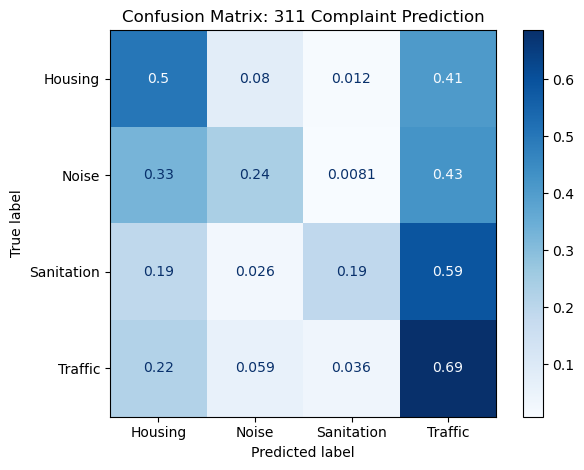

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(
    model, 
    X_test_enc, 
    y_test,
    display_labels=['Housing', 'Noise', 'Sanitation', 'Traffic'],
    cmap='Blues',
    normalize='true'  # Use 'true' for percentages, or remove for counts
)
plt.title('Confusion Matrix: 311 Complaint Prediction')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

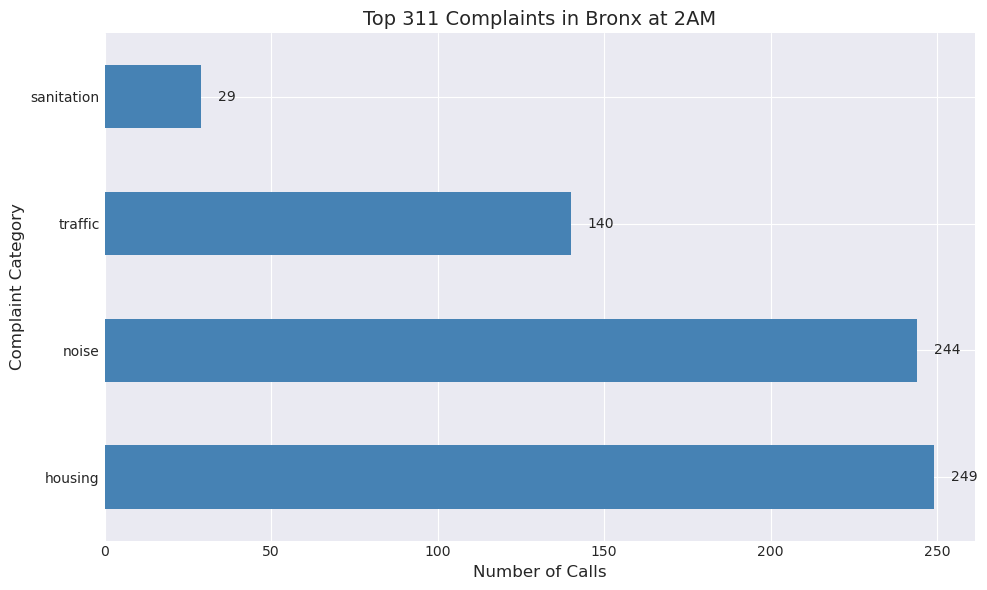

In [19]:
bronx_2am = df[(df["borough"] == "BRONX") & (df["hour_of_day"] == 2)]
top_complaints = bronx_2am["complaint_category"].value_counts()

plt.figure(figsize=(10, 6))
top_complaints.head(8).plot(kind='barh', color='steelblue')
plt.title("Top 311 Complaints in Bronx at 2AM", fontsize=14)
plt.xlabel("Number of Calls", fontsize=12)
plt.ylabel("Complaint Category", fontsize=12)

for i, v in enumerate(top_complaints.head(8).values):
    plt.text(v + 5, i, str(v), va='center')

plt.tight_layout()
plt.savefig('bronx_2am_complaints.png', dpi=300)
plt.show()

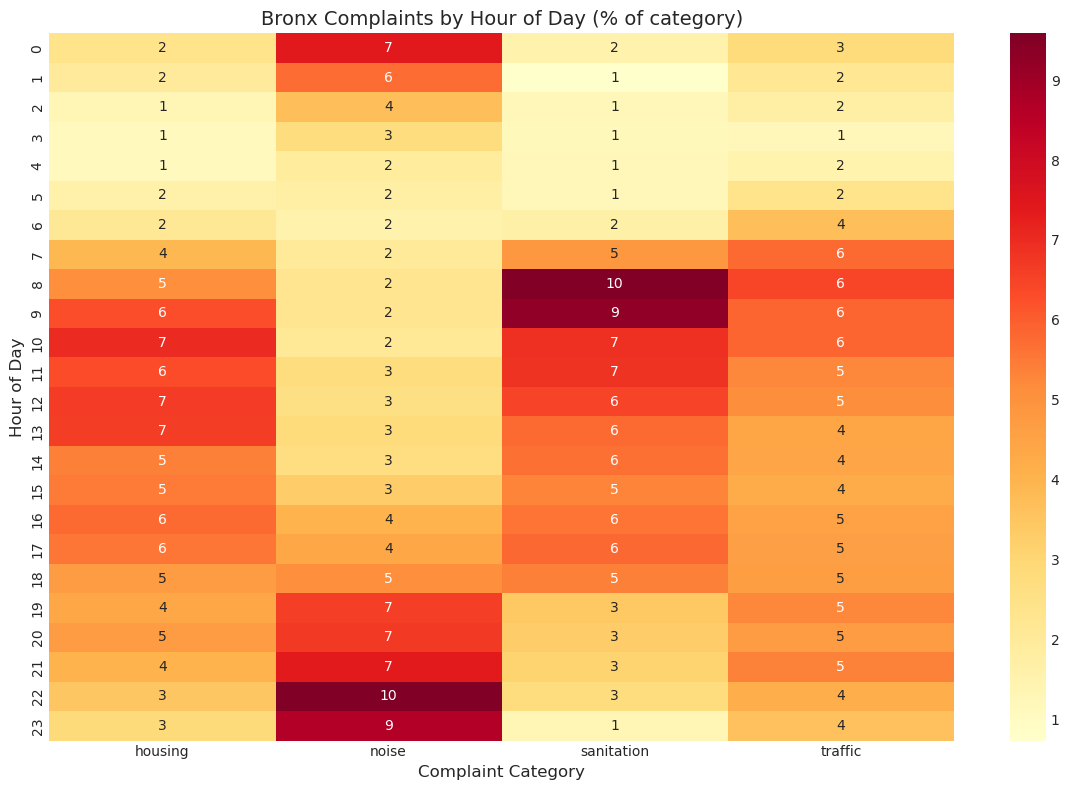

In [20]:
import seaborn as sns

# Filter to Bronx only
bronx_data = df[df["borough"] == "BRONX"]

# Create pivot table: hour_of_day vs complaint_category
pivot = pd.crosstab(bronx_data["hour_of_day"], 
                    bronx_data["complaint_category"],
                    normalize='columns') * 100

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f')
plt.title("Bronx Complaints by Hour of Day (% of category)", fontsize=14)
plt.xlabel("Complaint Category", fontsize=12)
plt.ylabel("Hour of Day", fontsize=12)
plt.tight_layout()
plt.savefig('bronx_hourly_heatmap.png', dpi=300)
plt.show()

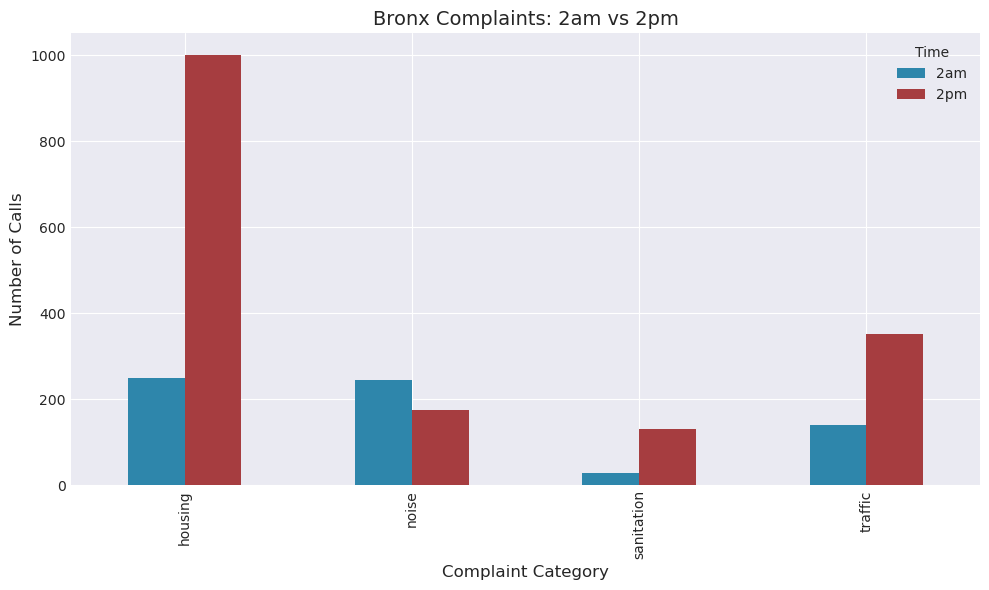

In [21]:
bronx_2am = df[(df["borough"] == "BRONX") & (df["hour_of_day"] == 2)]
bronx_2pm = df[(df["borough"] == "BRONX") & (df["hour_of_day"] == 14)]

am_counts = bronx_2am["complaint_category"].value_counts()
pm_counts = bronx_2pm["complaint_category"].value_counts()

comparison = pd.DataFrame({
    '2am': am_counts,
    '2pm': pm_counts
}).fillna(0).astype(int)

comparison.plot(kind='bar', figsize=(10, 6), color=['#2E86AB', '#A63D40'])
plt.title("Bronx Complaints: 2am vs 2pm", fontsize=14)
plt.xlabel("Complaint Category", fontsize=12)
plt.ylabel("Number of Calls", fontsize=12)
plt.legend(title="Time")
plt.tight_layout()
plt.savefig('bronx_2am_vs_2pm.png', dpi=300)
plt.show()

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     housing       0.53      0.50      0.52     11159
       noise       0.42      0.24      0.30      5039
  sanitation       0.56      0.19      0.28      3888
     traffic       0.46      0.69      0.55     11363

    accuracy                           0.49     31449
   macro avg       0.49      0.40      0.41     31449
weighted avg       0.49      0.49      0.47     31449

